## 02 - OOT time split + CatBoost training

Load the feature table from 01, split by time (first 80% train / last 20% test), train CatBoost, and save the model and split info for 03/04.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

ROOT = Path.cwd()
FEATURE_PATH = ROOT / "fraud_detection" / "data" / "features_processed.csv"
MODEL_DIR = ROOT / "fraud_detection" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEATURE_PATH)
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])
df = df.sort_values("transaction_datetime").reset_index(drop=True)
print("Shape:", df.shape)

Shape: (555719, 31)


## OOT time split (first 80% train, last 20% test)

In [2]:
train_ratio = 0.8
n = len(df)
split_idx = int(n * train_ratio)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]
print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Train period: {train_df['transaction_datetime'].min()} ~ {train_df['transaction_datetime'].max()}")
print(f"Test period:  {test_df['transaction_datetime'].min()} ~ {test_df['transaction_datetime'].max()}")
print(f"Train fraud rate: {train_df['is_fraud'].mean():.4f}")
print(f"Test fraud rate:  {test_df['is_fraud'].mean():.4f}")

Train: 444575, Test: 111144
Train period: 2020-06-21 12:14:00 ~ 2020-12-07 13:35:00
Test period:  2020-12-07 13:35:00 ~ 2020-12-31 23:59:00
Train fraud rate: 0.0044
Test fraud rate:  0.0017


## Feature columns and categorical features

In [3]:
target_col = "is_fraud"
drop_cols = ["transaction_datetime", "transaction_id", "customer_first_name", "customer_last_name", "customer_street", "customer_dob", "customer_id_number", "transaction_unix_time", target_col]
drop_cols = [c for c in drop_cols if c in df.columns]

cat_features = ["merchant_name", "merchant_category", "customer_gender", "customer_city", "customer_state", "customer_job_title"]
cat_features = [c for c in cat_features if c in df.columns]

feature_cols = [c for c in df.columns if c not in drop_cols and c != target_col]
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

cat_idx = [feature_cols.index(c) for c in cat_features if c in feature_cols]
print("Feature columns:", feature_cols)
print("Categorical:", cat_features)

Feature columns: ['merchant_name', 'merchant_category', 'transaction_amount', 'customer_gender', 'customer_city', 'customer_state', 'customer_zip', 'customer_latitude', 'customer_longitude', 'customer_city_population', 'customer_job_title', 'merchant_latitude', 'merchant_longitude', 'is_online', 'distance_to_merchant', 'effective_distance', 'hour_of_day', 'day_of_week', 'tx_count_1h', 'tx_count_24h', 'amt_sum_24h', 'customer_age']
Categorical: ['merchant_name', 'merchant_category', 'customer_gender', 'customer_city', 'customer_state', 'customer_job_title']


## Train CatBoost (scale_pos_weight)

In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_features,
    random_seed=42,
    verbose=100,
    eval_metric="AUC"
)
model.fit(X_train, y_train, eval_set=(X_test, y_test))
model.save_model(str(MODEL_DIR / "catboost_fraud.cbm"))
print(f"Model saved to {MODEL_DIR / 'catboost_fraud.cbm'}")

scale_pos_weight: 225.71
0:	test: 0.9437417	best: 0.9437417 (0)	total: 552ms	remaining: 4m 35s
100:	test: 0.9972286	best: 0.9972286 (100)	total: 21.3s	remaining: 1m 24s
200:	test: 0.9968304	best: 0.9976750 (121)	total: 42.8s	remaining: 1m 3s
300:	test: 0.9975735	best: 0.9976750 (121)	total: 1m 4s	remaining: 42.8s
400:	test: 0.9983614	best: 0.9984572 (397)	total: 1m 28s	remaining: 21.8s
499:	test: 0.9983651	best: 0.9985078 (416)	total: 1m 49s	remaining: 0us

bestTest = 0.9985077858
bestIteration = 416

Shrink model to first 417 iterations.
Model saved to /Users/zhumiban/Desktop/agent_bank/fraud_detection/models/catboost_fraud.cbm


## Evaluation: ROC-AUC / PR-AUC / threshold scan

Test ROC-AUC: 0.9985077858060876
Test PR-AUC: 0.870227665349316
Threshold 0.3: Precision=0.2348, Recall=0.9837
Threshold 0.5: Precision=0.3669, Recall=0.9511
Threshold 0.7: Precision=0.5413, Recall=0.8913


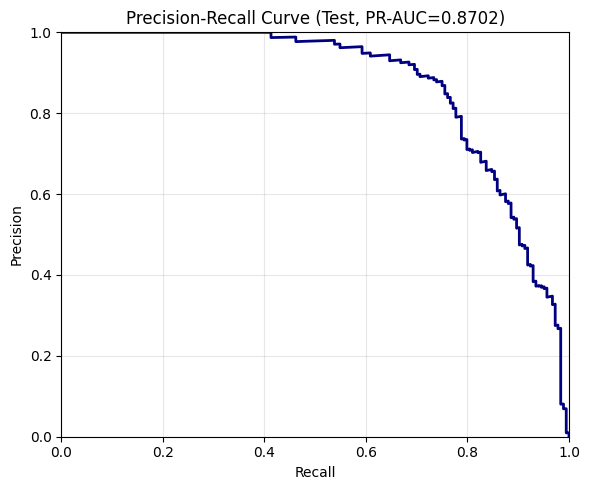

Saved PR curve to /Users/zhumiban/Desktop/agent_bank/fraud_detection/models/pr_curve.png


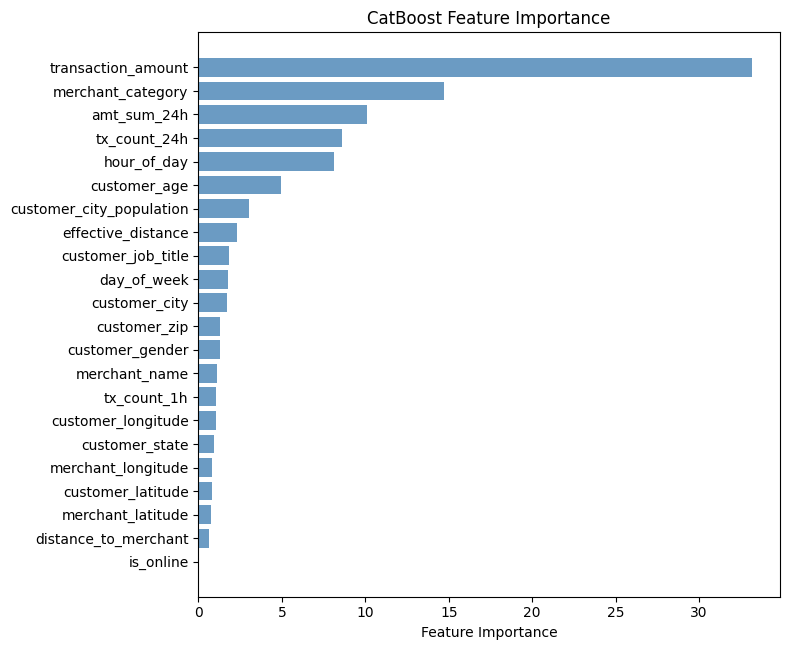

Saved feature importance to /Users/zhumiban/Desktop/agent_bank/fraud_detection/models/feature_importance.png
Saved OOT split and feature_config.json


In [5]:
y_prob = model.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Test PR-AUC:", average_precision_score(y_test, y_prob))

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
for th in [0.3, 0.5, 0.7]:
    pred = (y_prob >= th).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(y_test.sum(), 1)
    print(f"Threshold {th}: Precision={prec:.4f}, Recall={rec:.4f}")

train_df.to_csv(MODEL_DIR / "oot_train_index.csv", index=False)
test_df.to_csv(MODEL_DIR / "oot_test_index.csv", index=False)
with open(MODEL_DIR / "feature_config.json", "w") as f:
    json.dump({"feature_cols": feature_cols, "cat_features": cat_features}, f, indent=2)

# 1. Precision-Recall curve
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(recall, precision, color="navy", lw=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve (Test, PR-AUC={average_precision_score(y_test, y_prob):.4f})")
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
pr_curve_path = MODEL_DIR / "pr_curve.png"
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"Saved PR curve to {pr_curve_path}")

# 2. CatBoost feature importance bar chart
imp = model.get_feature_importance()
fi_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=True)
fig, ax = plt.subplots(1, 1, figsize=(8, max(6, len(feature_cols) * 0.3)))
ax.barh(fi_df["feature"], fi_df["importance"], color="steelblue", alpha=0.8)
ax.set_xlabel("Feature Importance")
ax.set_title("CatBoost Feature Importance")
plt.tight_layout()
fi_path = MODEL_DIR / "feature_importance.png"
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"Saved feature importance to {fi_path}")

print("Saved OOT split and feature_config.json")